# Tests where n_features > 1

In [1]:
from himalaya.ridge import BandedRidgeCV
import numpy as np
import torch

import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
T = 500
N = 8

X_1_scale = np.random.rand(T, N) / 5
X_2_scale = np.random.rand(T, N) / 5
Y_scale = np.random.rand(T, N) / 5

X_1 = np.expand_dims(np.linspace(-1, 1, T), axis=1) + np.random.randn(T, N) * X_1_scale
X_2 = np.expand_dims(np.linspace(1, -1, T), axis=1) + np.random.randn(T, N) * X_2_scale
Y = np.expand_dims(np.linspace(-1, 1, T), axis=1) + np.random.randn(T, N) * Y_scale

In [3]:
print(X_1)
print(X_1.shape)

[[-1.04687542 -0.95628153 -0.88613137 ... -0.99836603 -0.98785518
  -1.03489302]
 [-0.95015761 -1.00174242 -0.99638808 ... -1.04905828 -0.94385791
  -1.0642061 ]
 [-1.03365372 -1.00187763 -0.95636095 ... -1.00614801 -1.11625257
  -0.98966695]
 ...
 [ 0.96116883  0.98904258  0.98532957 ...  1.05741636  0.93516233
   1.04476397]
 [ 0.53500419  1.15119276  1.01381135 ...  0.98500432  0.9970349
   1.01032865]
 [ 1.47955935  1.01379224  1.06906638 ...  0.93583275  1.08713398
   1.00453336]]
(500, 8)


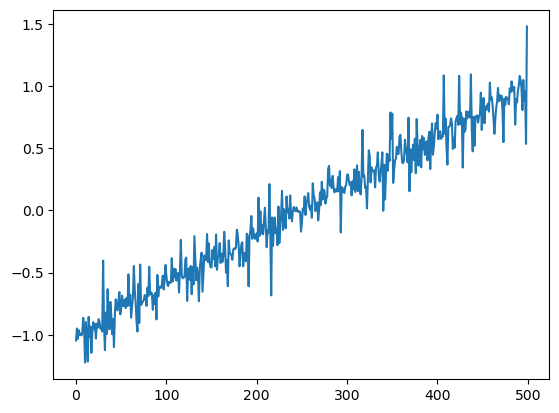

In [4]:
plt.plot(X_1[:, 0])

## Fit model

In [5]:
X = [X_1, X_2]
solver_params = {
    "alphas": np.logspace(3, 5, 20, base=2)
}

model = BandedRidgeCV(groups="input", cv=5, solver_params=solver_params)  # cv should be 50
model.fit(X, Y)

🙏 02/15/2025 Updates in _sklearn_api.py
🐛 02/15/2025 Updates in _random_search.py > random search
[........................................] 100% | 0.93 sec | 100 random sampling with cv | 


GroupRidgeCV(groups='input',
             solver_params={'alphas': array([ 8.        ,  8.60552469,  9.2568819 ,  9.95754072, 10.71123281,
       11.5219723 , 12.39407714, 13.3321921 , 14.34131354, 15.42681597,
       16.59448071, 17.85052668, 19.20164351, 20.65502717, 22.21841828,
       23.90014339, 25.70915925, 27.65510059, 29.74833136, 32.        ])})

In [6]:
best_alphas_ = model.best_alphas_
best_gammas_ = model.best_gammas_

In [7]:
print(best_alphas_)
print(best_gammas_)
print(len(best_alphas_))

[ 8.          8.          8.          8.         10.71123281  8.
  8.          8.        ]
[[0.5        0.62379549 0.39417589 0.57581989 0.49391684 0.60363417
  0.55751008 0.60363417]
 [0.5        0.37620451 0.60582411 0.42418011 0.50608316 0.39636583
  0.44248992 0.39636583]]
8


## Deterministic Solver

In [8]:
# Determinstic solver model
md = BandedRidgeCV(groups="input", cv=50, solver="deterministic", hparams=(best_gammas_, best_alphas_))

In [9]:
print(len(X))
md.fit(X, Y)

2
🙏 02/15/2025 Updates in _sklearn_api.py
🐛 02/15/2025 Updates in _random_search.py > deterministic
🐛 At _random_search.py deterministic: refit_weights initial shape (16, 8)
best_gammas processed:  [[0.39417589 0.60582411]
 [0.49391684 0.50608316]
 [0.5        0.5       ]
 [0.55751008 0.44248992]
 [0.57581989 0.42418011]
 [0.60363417 0.39636583]
 [0.62379549 0.37620451]]
[........................................] 100% | 0.01 sec | Deterministic fitting with cv | 


GroupRidgeCV(cv=50, groups='input',
             hparams=(array([[0.5       , 0.62379549, 0.39417589, 0.57581989, 0.49391684,
        0.60363417, 0.55751008, 0.60363417],
       [0.5       , 0.37620451, 0.60582411, 0.42418011, 0.50608316,
        0.39636583, 0.44248992, 0.39636583]]),
                      array([ 8.        ,  8.        ,  8.        ,  8.        , 10.71123281,
        8.        ,  8.        ,  8.        ])),
             solver='deterministic')

In [10]:
X_1t = np.expand_dims(np.linspace(-1, 1, T), axis=1) + np.random.randn(T, N) * X_1_scale
X_2t = np.expand_dims(np.linspace(1, -1, T), axis=1) + np.random.randn(T, N) * X_2_scale

In [11]:
Y_pred = md.predict([X_1t, X_2t])

In [12]:
md.score([X_1t, X_2t], Y_pred)

array([1., 1., 1., 1., 1., 1., 1., 1.])

## Debugging

In [13]:
primal_weights = [[ 0.06100893],
 [ 0.05109481],
 [ 0.05409537],
 [ 0.04774888],
 [ 0.04920689],
 [ 0.03810651],
 [ 0.05219887],
 [ 0.05831511],
 [-0.08047608],
 [-0.0887123 ],
 [-0.06718514],
 [-0.056766  ],
 [-0.06021122],
 [-0.08971488],
 [-0.07275169],
 [-0.05790131]]
primal_weights = np.array(primal_weights)

In [14]:
primal_weights[:,None].shape

(16, 1, 1)

In [15]:
print(best_gammas_)

[[0.5        0.62379549 0.39417589 0.57581989 0.49391684 0.60363417
  0.55751008 0.60363417]
 [0.5        0.37620451 0.60582411 0.42418011 0.50608316 0.39636583
  0.44248992 0.39636583]]


In [16]:
fgu = np.unique(best_gammas_)
print(len(fgu))


13


In [17]:
print(best_gammas_.shape)

(2, 8)


In [18]:
gamma_pairs = set([(i, j) for i, j in zip(best_gammas_[0], best_gammas_[1])])
for i, j in gamma_pairs:
    print(i, j)

0.5 0.5
0.6036341734056867 0.39636582659431335
0.5575100805263435 0.44248991947365657
0.5758198921557846 0.42418010784421534
0.6237954904348999 0.37620450956510004
0.3941758930098587 0.6058241069901411
0.49391683575192274 0.5060831642480771


In [19]:
print(best_gammas_)
gp = np.unique(best_gammas_, axis=1)
print(gp)

[[0.5        0.62379549 0.39417589 0.57581989 0.49391684 0.60363417
  0.55751008 0.60363417]
 [0.5        0.37620451 0.60582411 0.42418011 0.50608316 0.39636583
  0.44248992 0.39636583]]
[[0.39417589 0.49391684 0.5        0.55751008 0.57581989 0.60363417
  0.62379549]
 [0.60582411 0.50608316 0.5        0.44248992 0.42418011 0.39636583
  0.37620451]]


In [20]:
a = np.array([[1,2,3,3,4,5,5,5,6], [2,1,1,1,4,5,6,8,9]])

In [21]:
a

array([[1, 2, 3, 3, 4, 5, 5, 5, 6],
       [2, 1, 1, 1, 4, 5, 6, 8, 9]])

In [22]:
# Finding at indices a gamma pair target appears
print(a.T)
print(np.where(a.T == [3, 1]))
cond = a.T == [3, 1]
cond = cond[:, 0] * cond[:, 1]
print(cond)
cond = cond.nonzero()
print(cond)


[[1 2]
 [2 1]
 [3 1]
 [3 1]
 [4 4]
 [5 5]
 [5 6]
 [5 8]
 [6 9]]
(array([1, 2, 2, 3, 3]), array([1, 0, 1, 0, 1]))
[False False  True  True False False False False False]
(array([2, 3]),)


In [23]:
alphas_computed = best_gammas_/np.exp(model.deltas_)

In [24]:
print(alphas_computed)
print(alphas_computed[0] == alphas_computed[1])  # Numerical instability, it seems. 
                                                    # Probably need a comparator with tolerance

[[ 8.          8.          8.          8.         10.71123281  8.
   8.          8.        ]
 [ 8.          8.          8.          8.         10.71123281  8.
   8.          8.        ]]
[ True False False False False  True False  True]
